In [1]:
import os
import sys
from pathlib import Path
import importlib
import torch

In [2]:
#@title Mount Goole Drive

root_path = "/content/drive/MyDrive/MSc/Flood-Mapping"  #@param {type:"string", multiline:true}


mount_drive = True  #@param {type:"boolean"}

clone_repo = False  #@param {type:"boolean"}

if clone_repo and mount_drive:

    from google.colab import drive
    drive.mount("/content/drive")

    root_path = os.path.join(root_path, "Flood-Mapping")

    !git clone https://github.com/TAX2310/Flood-Mapping.git $root_path

    sys.path.append(os.path.join(root_path))

    from src.config import S1_CFG
    cfg = S1_CFG()

    cfg.ROOT = Path(root_path)

elif not clone_repo and mount_drive:
    from google.colab import drive
    drive.mount("/content/drive")

    sys.path.append(os.path.join(root_path))

    from src.config import S1_CFG
    cfg = S1_CFG()

    cfg.ROOT = Path(root_path)

elif clone_repo and not mount_drive:
    root_path = "Flood-Mapping"

    !git clone https://github.com/TAX2310/Flood-Mapping.git

    sys.path.append(root_path)

    from src.config import S1_CFG
    cfg = S1_CFG()

    cfg.ROOT = Path(root_path)

else:
    from src.config import S1_CFG
    cfg = S1_CFG()

    sys.path.append(os.path.join(cfg.ROOT))

cfg.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Mounted at /content/drive


In [3]:
requirements = cfg.ROOT / "requirements.txt"
!pip install -r {requirements}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.5 MB/s eta 0:00:00


In [4]:
import src.train.training as training
import src.test.testing as testing
import src.util.io as io
import src.util.plotting as plot

In [6]:
learning_rates = [1e-3, 1e-4]
batch_sizes = [32, 64]
weight_decays = [0.0, 1e-5]
dropout_rates = [0.0, 0.2]

num_workers = 8

In [ ]:
for learning_rate in learning_rates:
    for batch_size in batch_sizes:
        for weight_decay in weight_decays:
            for dropout_rate in dropout_rates:
                cfg.LR = learning_rate
                cfg.BATCH_SIZE = batch_size
                cfg.WEIGHT_DECAY = weight_decay
                cfg.DROPOUT_RATE = dropout_rate
                training.train_from_file(cfg, num_workers=num_workers)

Found 16 model subdirectories in /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Sentinel1_SAR


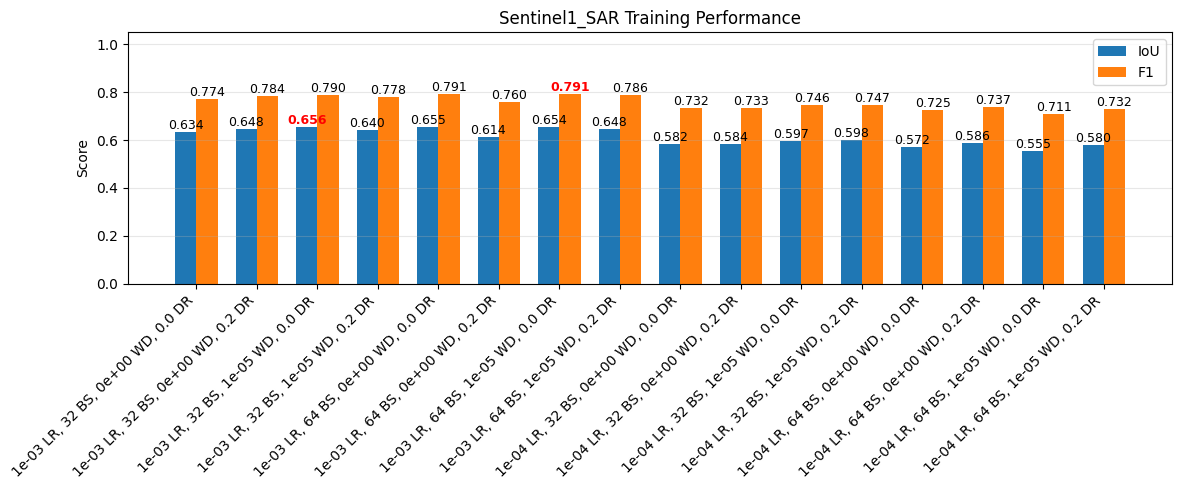

In [5]:
plot.view_f1_iou_bar(cfg)

In [6]:
plot.view_training_metrics(cfg)

Dropdown(description='Model:', layout=Layout(width='700px'), options=(PosixPath('/content/drive/MyDrive/MSc/Fl…

Button(description='Plot metrics', style=ButtonStyle())

Output()

In [ ]:
import src.inference.inference as inference

samples = ["EMSR470_AOI01_46_07_2_1.tif",
           "EMSR441_AOI05_2_3_2_2.tif",
           "EMSR570_AOI02_07_03_2_1.tif"
]

results = inference.inference(cfg, cfg.S1_MODEL, samples)
all_results = inference.inference(cfg, cfg.S1_MODEL)
io.create_test_results_csv(cfg, all_results, cfg.METADATA_CSV, cfg.S1_TEST_RESULTS_CSV)

Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Sentinel1_SAR/lr_0.001/bs_32/wd_1e-05/dr_0.0
Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Sentinel1_SAR/lr_0.001/bs_32/wd_1e-05/dr_0.0


,Unnamed: 0,ems_code,aoi_code,floodmap_id,event_type,country,tile_id,floodmap_date,sentinel2_timestamp,sentinel1_timestamp,...,accuracy,precision,recall,f1,iou,flood_pixels,non_flood_pixels,ignored_pixels,total_valid_pixels,flood_pixel_percentage
0,1212,EMSR470,AOI01,EMSR470_AOI01_DEL_PRODUCT,Flash flood,Togo,EMSR470_AOI01_14_25_2_2.tif,2020-10-14 20:11:00,2020-10-13 10:19:09,14/10/2020 18:11,...,0.976196,0.693878,1.000000,0.819277,0.693878,884,15500,0,16384,0.053955
1,2673,EMSR629,AOI02,EMSR629_AOI02_DEL_PRODUCT,Riverine flood,Pakistan,EMSR629_AOI02_01_13_2_1.tif,2022-08-30 07:45:00,2022-08-31 05:56:51,30/08/2022 01:25,...,0.822815,0.899620,0.678835,0.773786,0.631037,7314,9070,0,16384,0.446411
2,2630,EMSR570,AOI02,EMSR570_AOI02_DEL_MONIT01,Riverine flood,Australia,EMSR570_AOI02_07_03_2_1.tif,2022-03-31 08:44:00,2022-03-31 23:52:39,31/03/2022 19:14,...,0.741455,0.789940,0.660669,0.719544,0.561944,8225,8159,0,16384,0.502014
3,1932,EMSR479,AOI02,EMSR479_AOI02_DEL_PRODUCT,Flash flood,Mexico,EMSR479_AOI02_27_22_2_2.tif,2020-11-08 17:35:00,2020-11-08 16:35:11,09/11/2020 12:01,...,0.879211,0.961580,0.860765,0.908384,0.832146,11398,4986,0,16384,0.695679
4,2202,EMSR479,AOI02,EMSR479_AOI02_DEL_PRODUCT,Flash flood,Mexico,EMSR479_AOI02_43_51_1_1.tif,2020-11-08 17:35:00,2020-11-08 16:35:11,09/11/2020 12:02,...,0.982910,0.000000,0.000000,0.000000,0.000000,278,16106,0,16384,0.016968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,1174,EMSR470,AOI01,EMSR470_AOI01_DEL_PRODUCT,Flash flood,Togo,EMSR470_AOI01_11_25_1_2.tif,2020-10-14 20:11:00,2020-10-13 10:19:09,14/10/2020 18:11,...,0.936829,0.559949,1.000000,0.717907,0.559949,1317,15067,0,16384,0.080383
194,2138,EMSR479,AOI02,EMSR479_AOI02_DEL_PRODUCT,Flash flood,Mexico,EMSR479_AOI02_34_40_2_2.tif,2020-11-08 17:35:00,2020-11-08 16:35:11,09/11/2020 12:01,...,0.909546,0.550904,0.921053,0.689438,0.526063,1786,14598,0,16384,0.109009
195,67,EMSR279,05ZARAGOZA,EMSR279_05ZARAGOZA_DEL_v2,Riverine flood,Spain,EMSR279_05ZARAGOZA_08_12_1_1.tif,2018-04-13 19:52:00,2018-04-14 10:56:51,13/04/2018 17:54,...,0.537109,0.998569,0.269186,0.424058,0.269082,10372,6012,0,16384,0.633057
196,508,EMSR407,AOI01,EMSR407_AOI01_DEL_PRODUCT,Flash flood,United Kingdom,EMSR407_AOI01_12_16_2_1.tif,2019-11-14 19:02:00,2019-11-13 11:12:19,14/11/2019 06:14,...,0.953308,0.687783,0.179245,0.284378,0.165758,848,15536,0,16384,0.051758


id: torch.Size([1])
sample_id: EMSR441_AOI05_2_3_2_2.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR441_AOI05_2_3_2_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR441_AOI05_2_3_2_2.tif
accuracy: 0.97406005859375
precision: 0.0
recall: 0.0
f1: 0.0
iou: 0.0


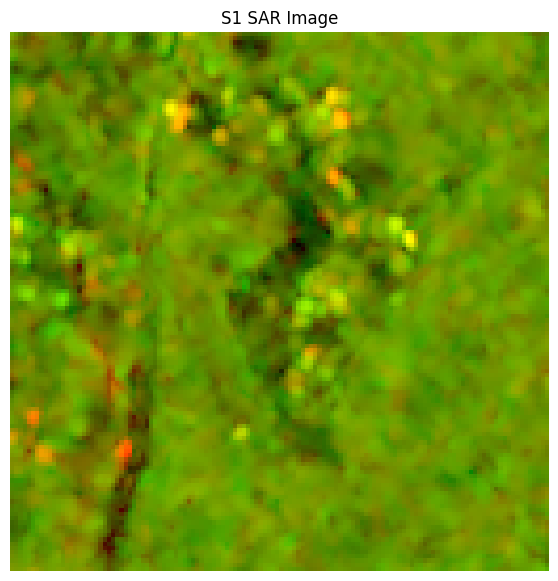

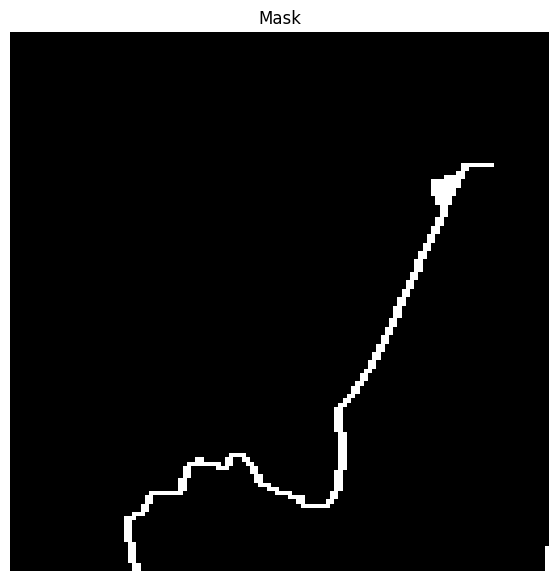

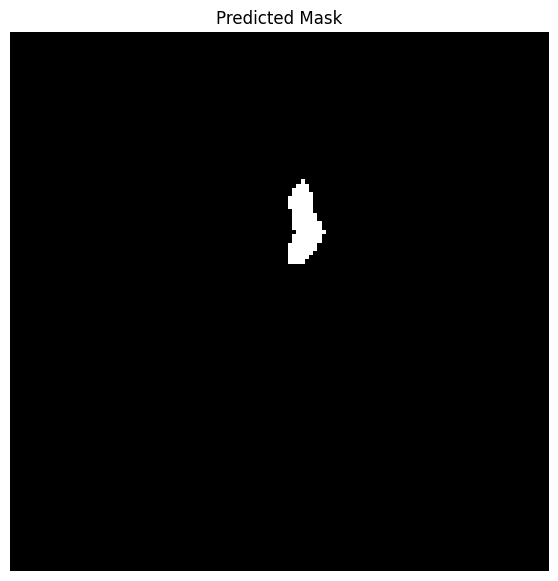

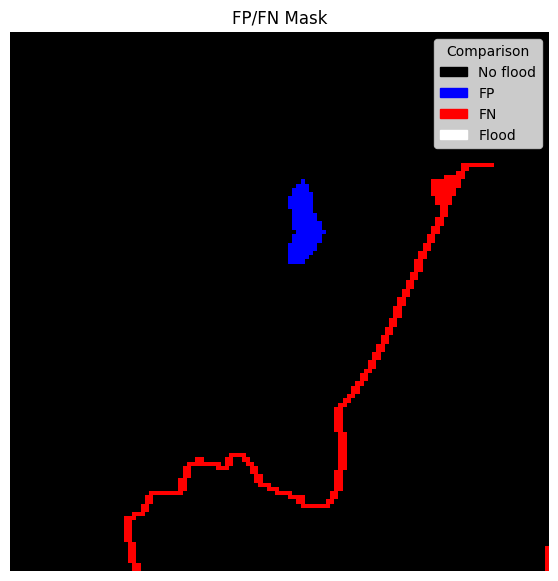

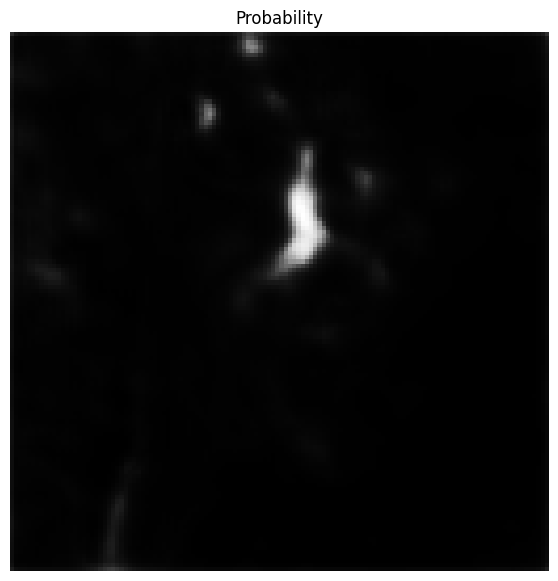

id: torch.Size([1])
sample_id: EMSR470_AOI01_46_07_2_1.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR470_AOI01_46_07_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_46_07_2_1.tif
accuracy: 0.992431640625
precision: 0.9854379296302795
recall: 0.9887288808822632
f1: 0.9870805740356445
iou: 0.9744908213615417


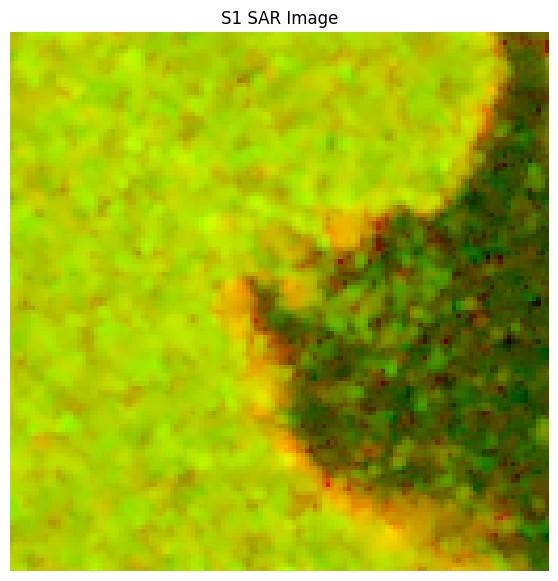

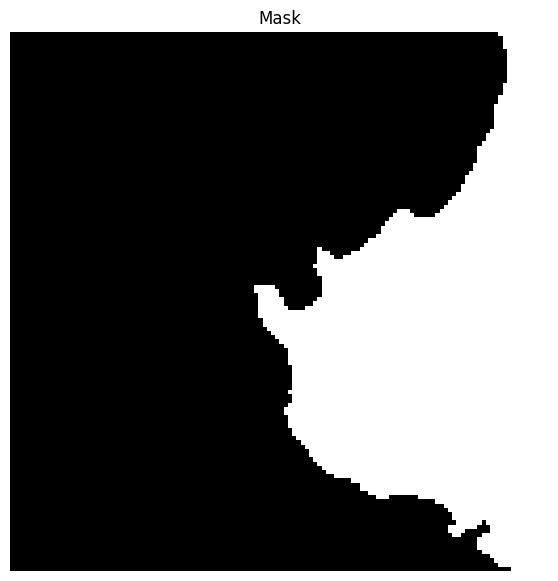

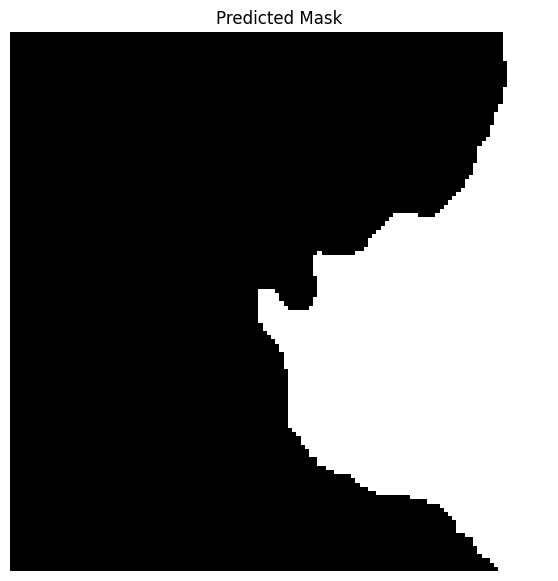

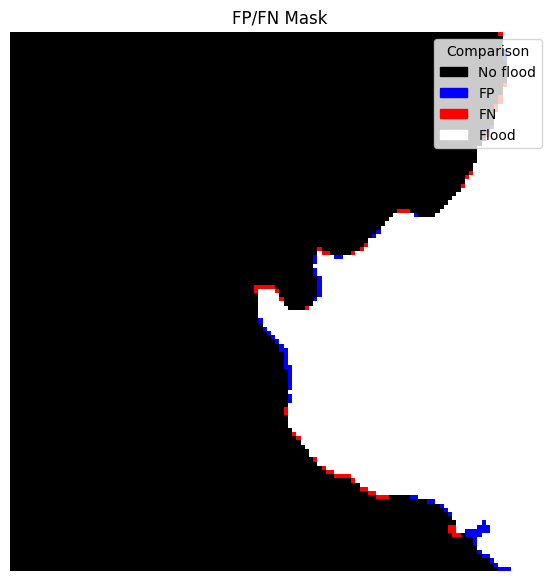

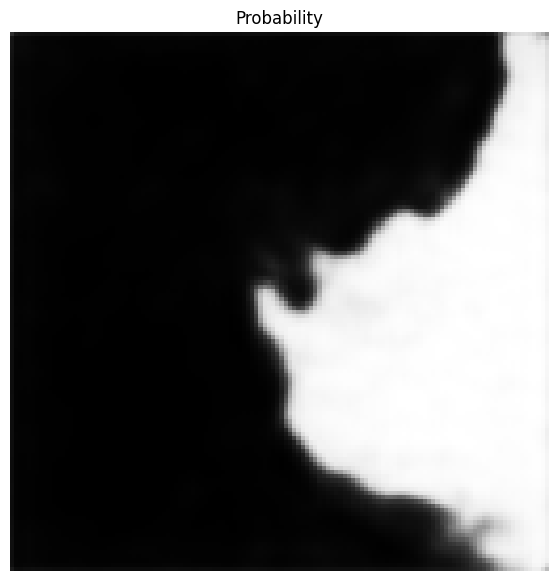

id: torch.Size([1])
sample_id: EMSR570_AOI02_07_03_2_1.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR570_AOI02_07_03_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR570_AOI02_07_03_2_1.tif
accuracy: 0.741455078125
precision: 0.7899404168128967
recall: 0.660668671131134
f1: 0.7195444703102112
iou: 0.5619441866874695


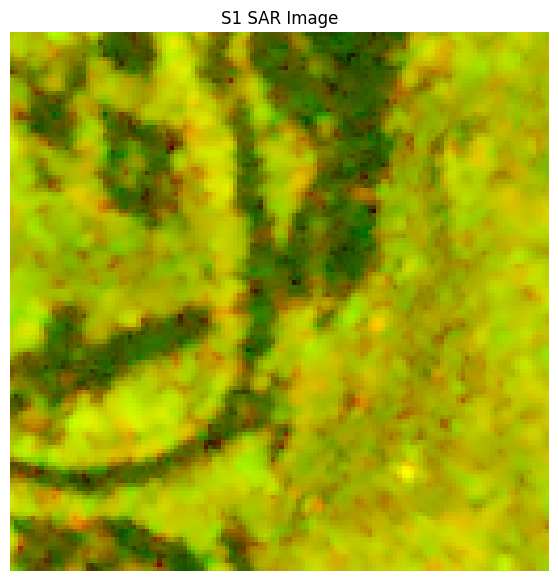

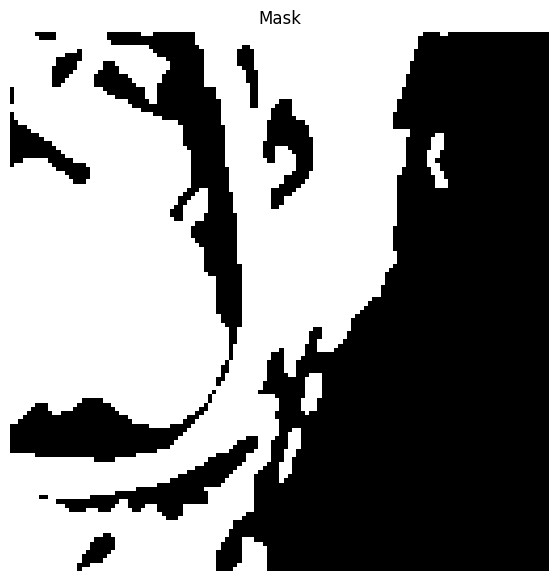

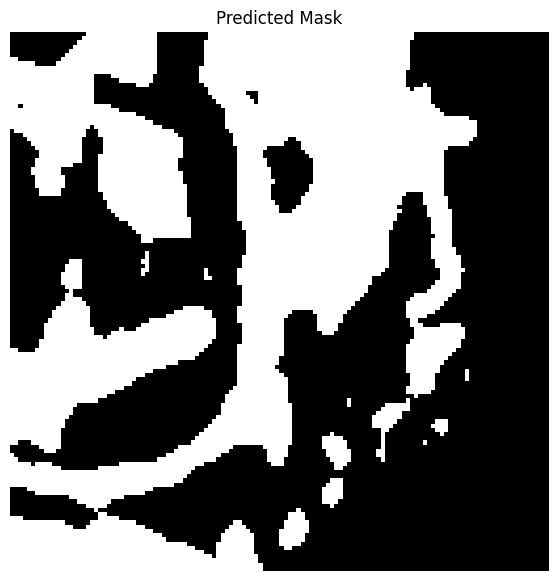

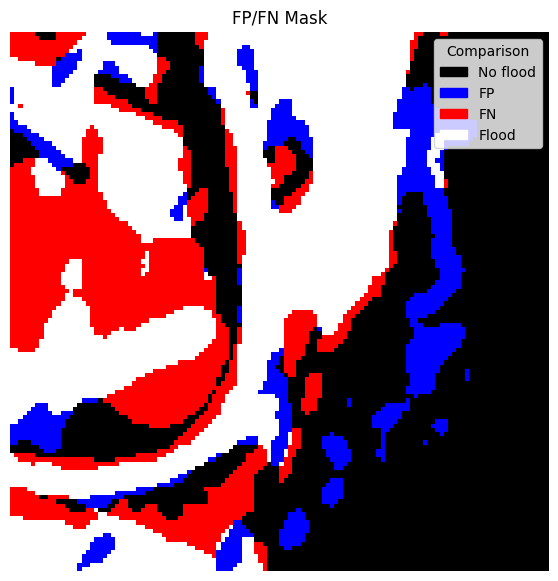

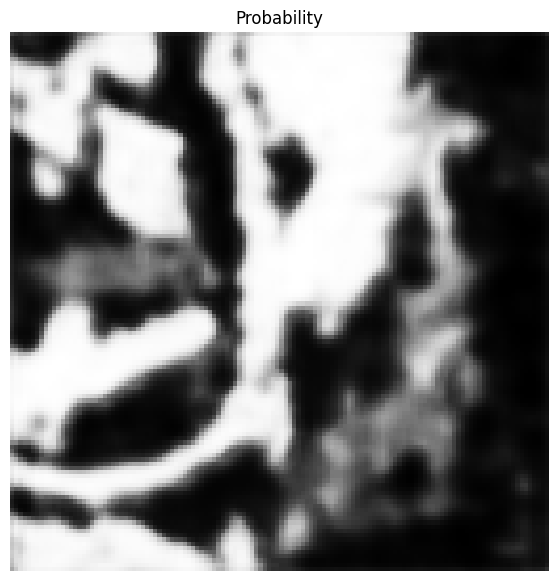

In [ ]:
plot.plot_s1_results(results)

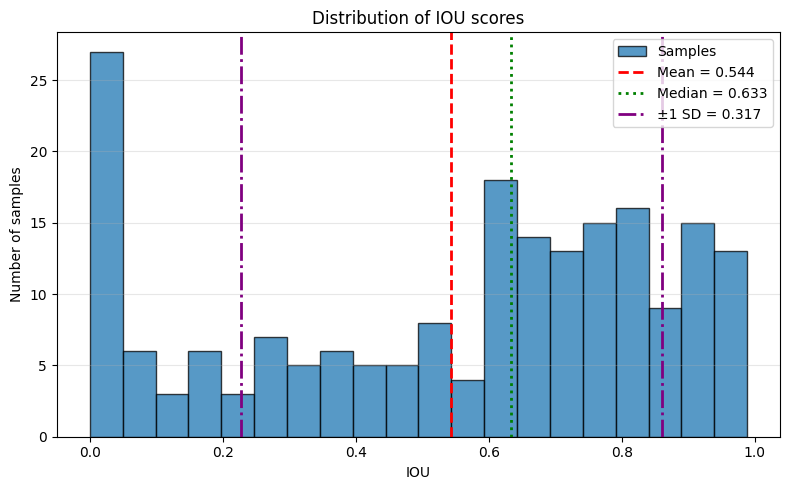

In [6]:
plot.plot_metric_distribution_from_csv(cfg.S1_TEST_RESULTS_CSV)

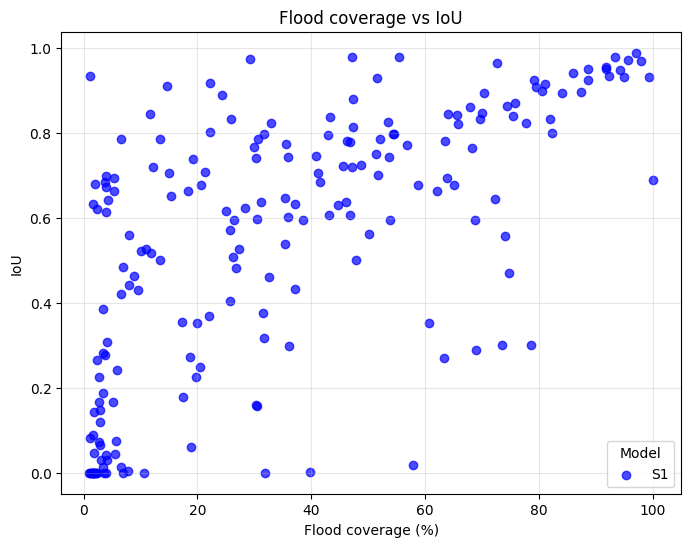

In [7]:
plot.plot_iou_vs_flood_scatter([cfg.S1_TEST_RESULTS_CSV])

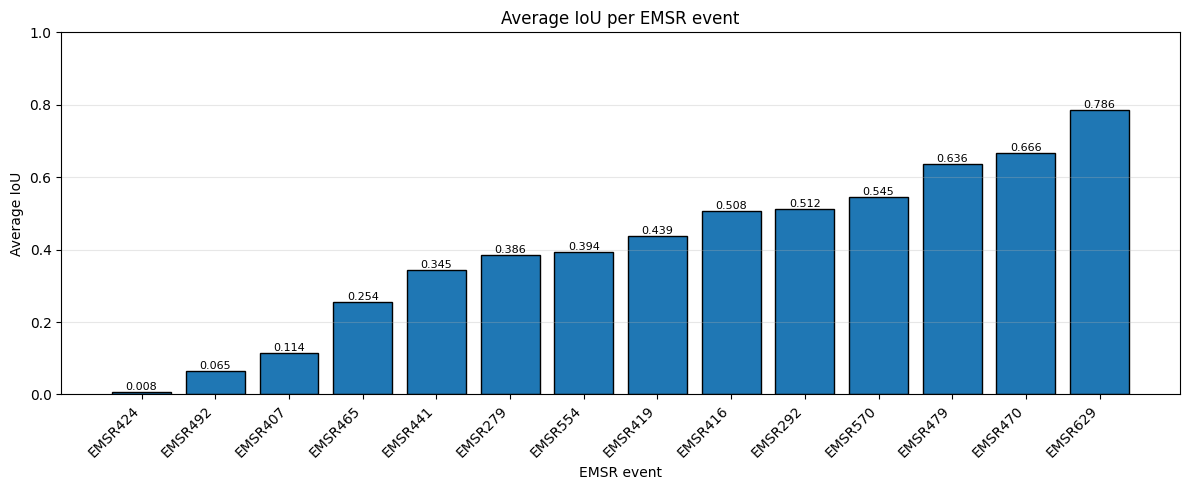

,event_id,mean_iou
5,EMSR424,0.007750
10,EMSR492,0.064935
2,EMSR407,0.113883
7,EMSR465,0.254147
6,EMSR441,0.344900
0,EMSR279,0.386231
11,EMSR554,0.394357
4,EMSR419,0.438535
3,EMSR416,0.507856
1,EMSR292,0.512480


In [8]:
plot.plot_average_iou_per_event(cfg.S1_TEST_RESULTS_CSV)

In [8]:
import src.inference.inference as inference

samples = ["EMSR407_AOI01_03_17_2_1.tif",
           "EMSR470_AOI01_29_13_2_2.tif",
           "EMSR470_AOI01_10_25_1_1.tif",
           "EMSR470_AOI01_47_10_1_2.tif",
           "EMSR629_AOI01_08_02_1_1.tif",
           "EMSR629_AOI01_09_01_1_2.tif"
]


results = inference.inference(cfg, cfg.S1_MODEL, samples)

Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Sentinel1_SAR/lr_0.001/bs_32/wd_1e-05/dr_0.0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


id: torch.Size([1])
sample_id: EMSR407_AOI01_03_17_2_1.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR407_AOI01_03_17_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR407_AOI01_03_17_2_1.tif
accuracy: 0.91229248046875
precision: 0.04330708831548691
recall: 0.08644400537014008
f1: 0.057704877108335495
iou: 0.029709655791521072


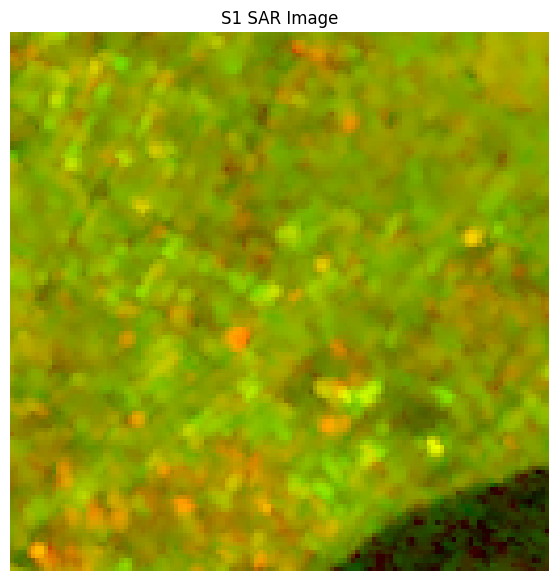

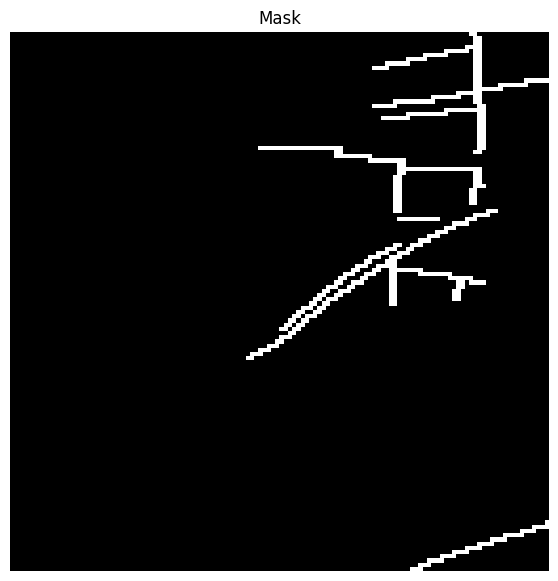

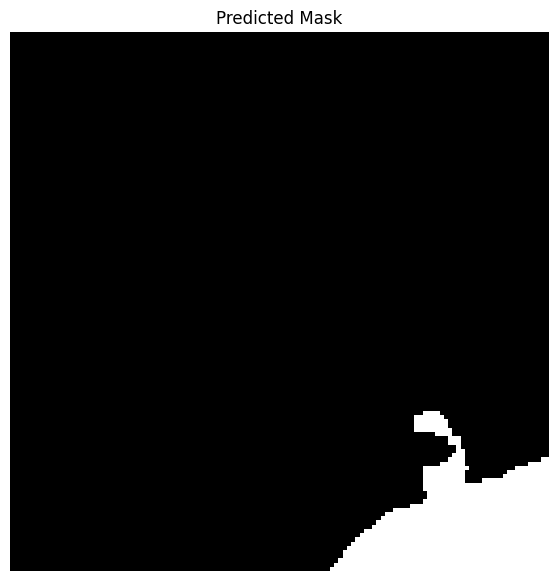

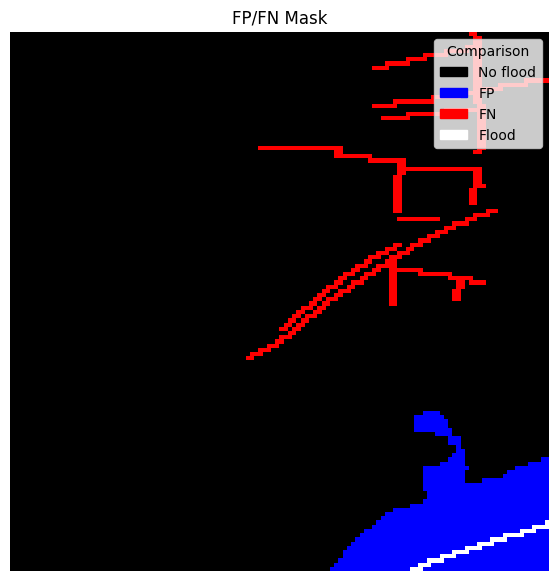

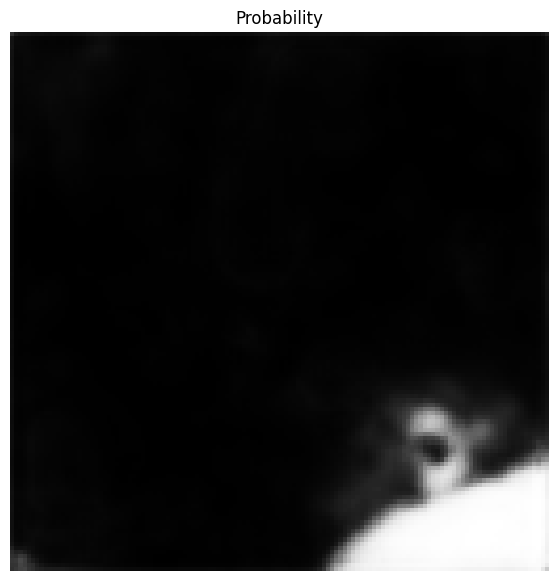

id: torch.Size([1])
sample_id: EMSR470_AOI01_10_25_1_1.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR470_AOI01_10_25_1_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_10_25_1_1.tif
accuracy: 0.8857421875
precision: 0.9118082523345947
recall: 0.6618689298629761
f1: 0.7669902443885803
iou: 0.6220472455024719


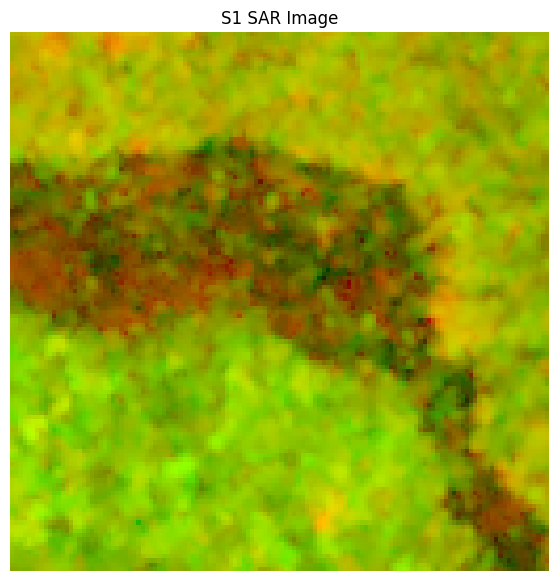

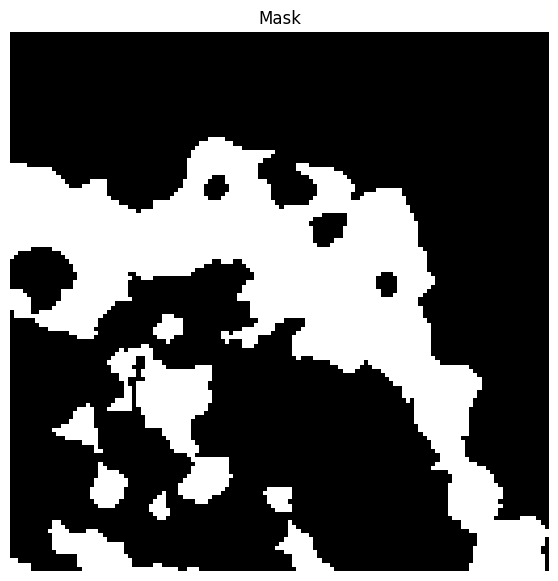

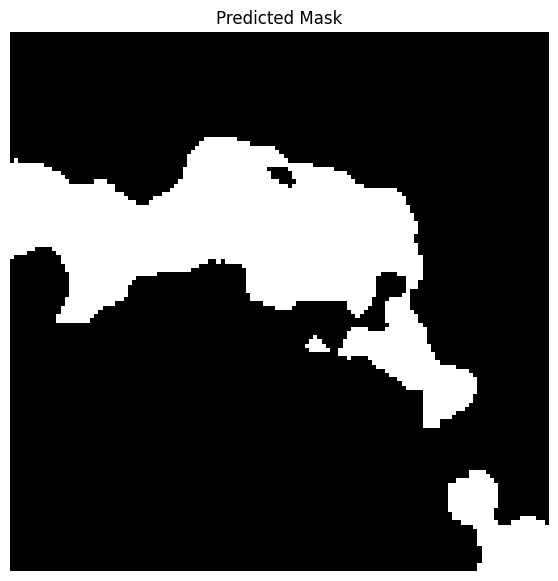

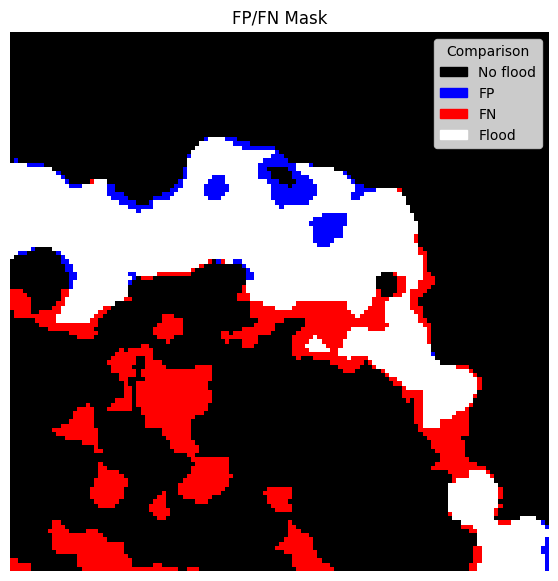

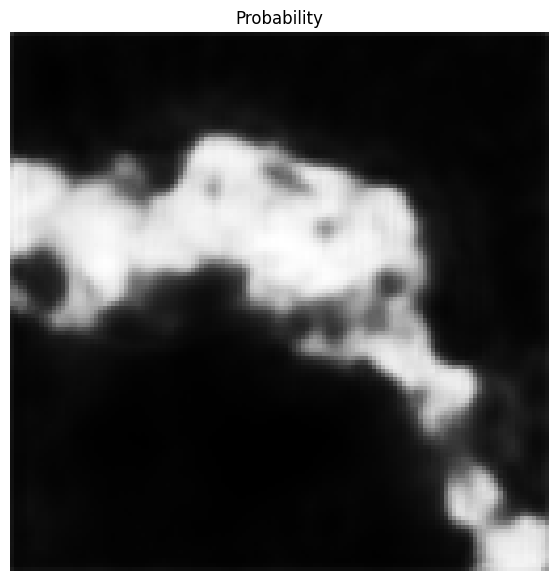

id: torch.Size([1])
sample_id: EMSR470_AOI01_29_13_2_2.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR470_AOI01_29_13_2_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_29_13_2_2.tif
accuracy: 0.9879150390625
precision: 0.9897328615188599
recall: 0.9884233474731445
f1: 0.989077627658844
iou: 0.9783913493156433


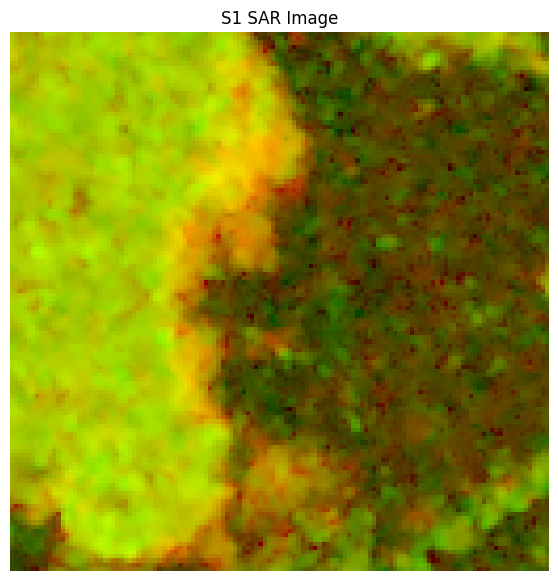

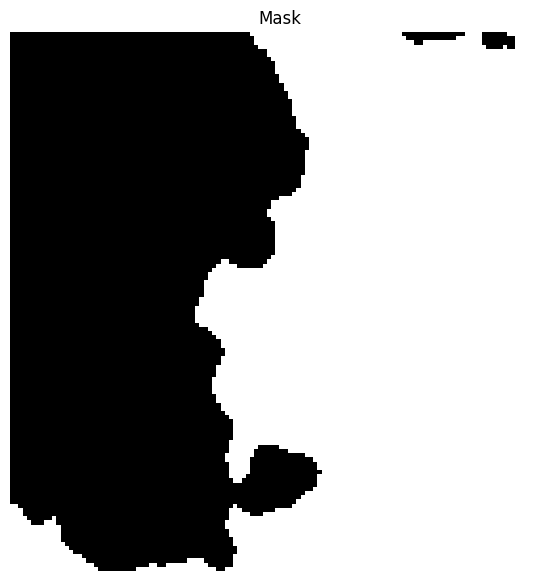

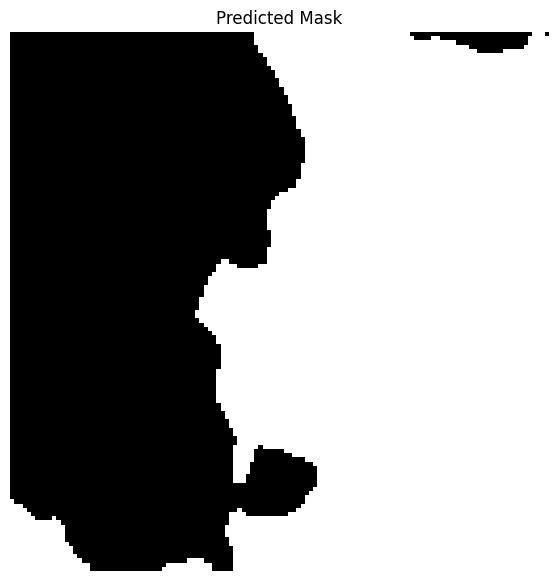

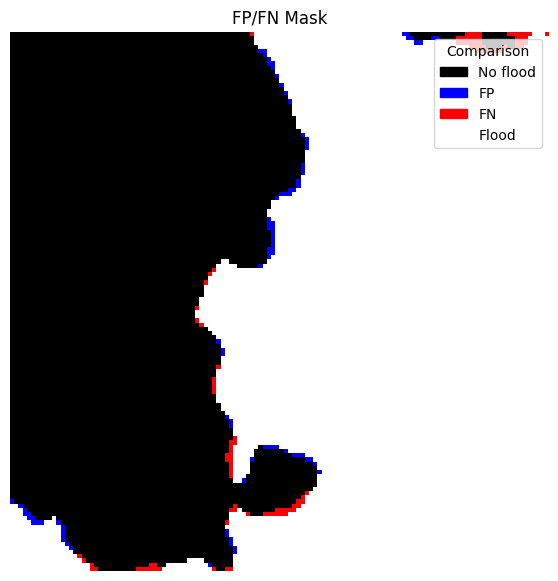

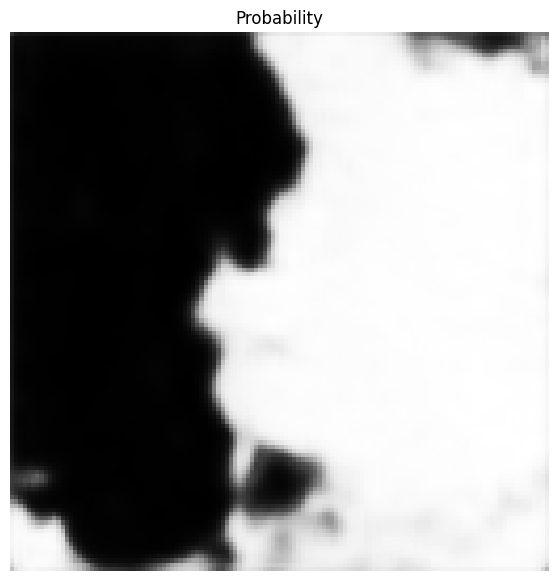

id: torch.Size([1])
sample_id: EMSR470_AOI01_47_10_1_2.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR470_AOI01_47_10_1_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_47_10_1_2.tif
accuracy: 0.95849609375
precision: 0.8086591958999634
recall: 0.865902304649353
f1: 0.8363022804260254
iou: 0.718659520149231


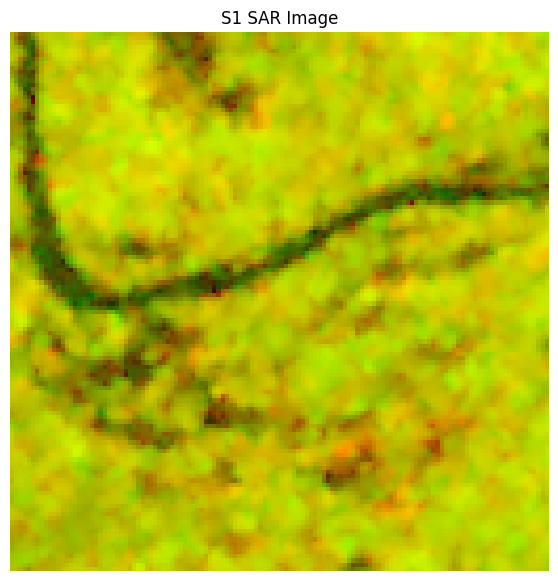

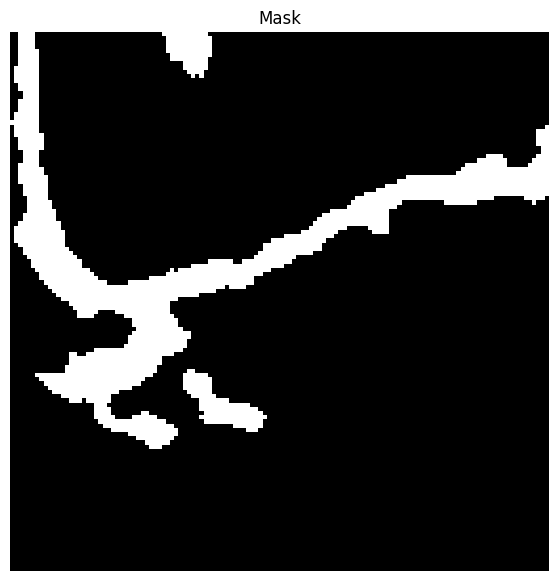

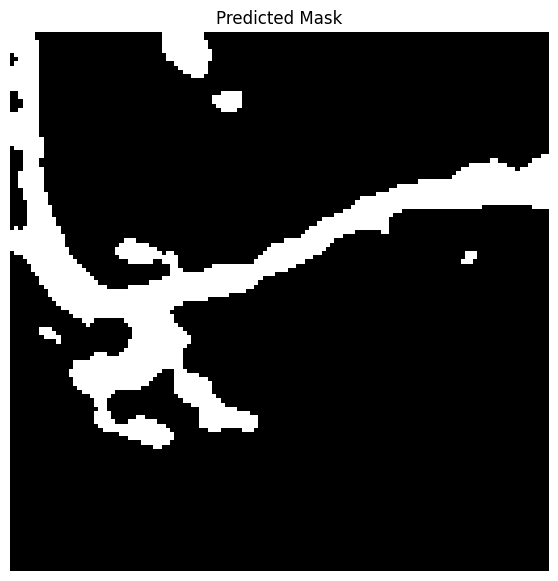

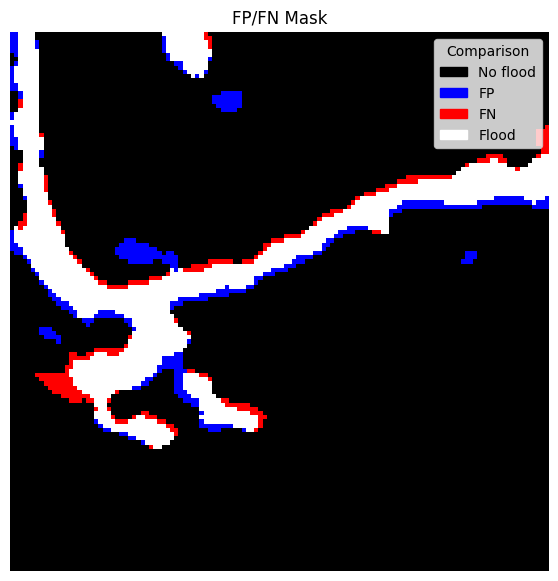

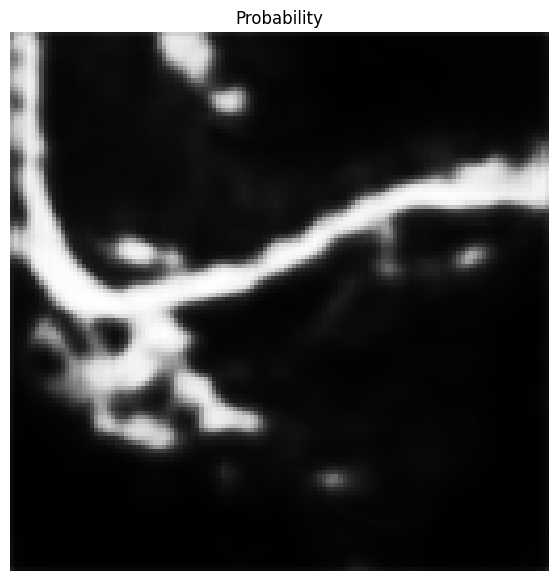

id: torch.Size([1])
sample_id: EMSR629_AOI01_08_02_1_1.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR629_AOI01_08_02_1_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR629_AOI01_08_02_1_1.tif
accuracy: 0.93365478515625
precision: 0.9877949953079224
recall: 0.9417550563812256
f1: 0.964225709438324
iou: 0.9309227466583252


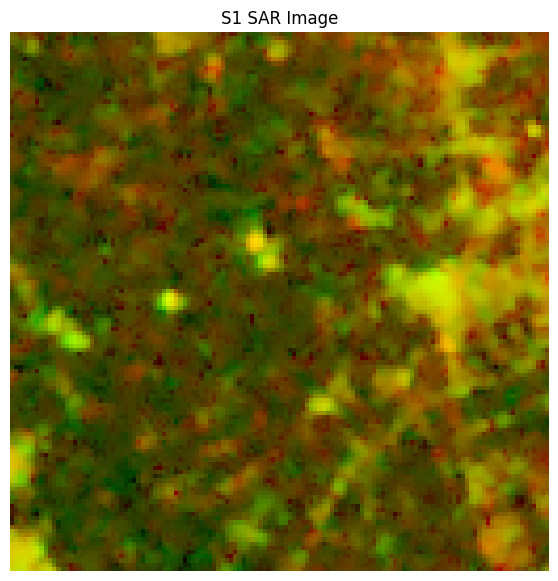

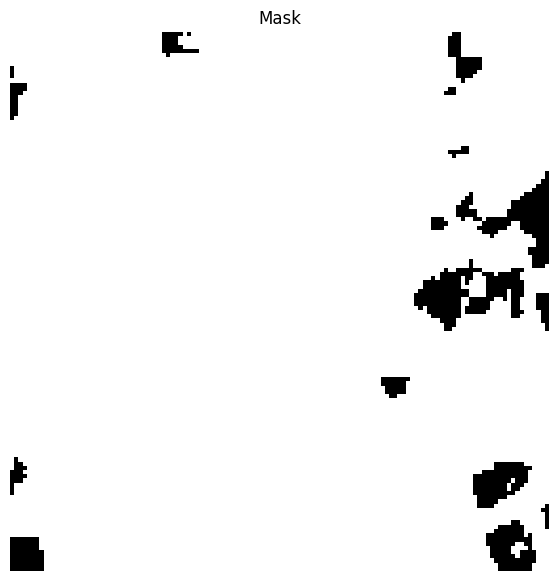

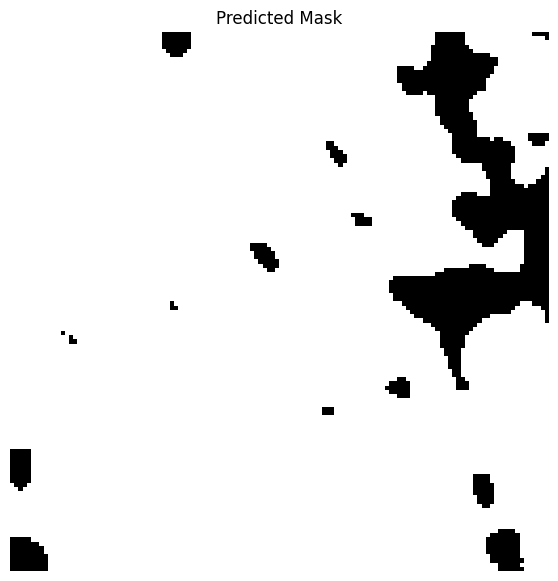

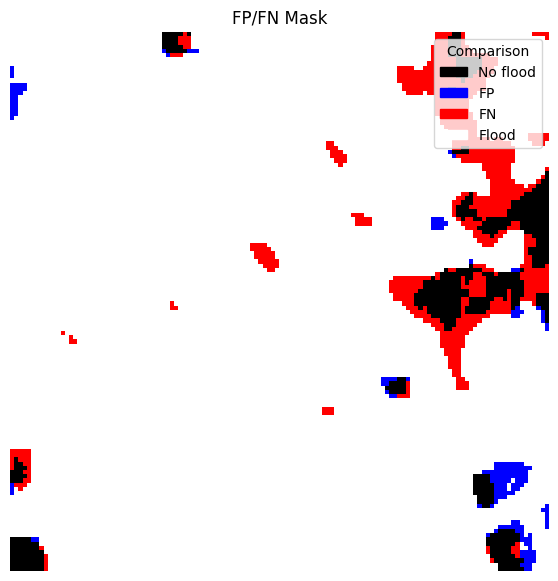

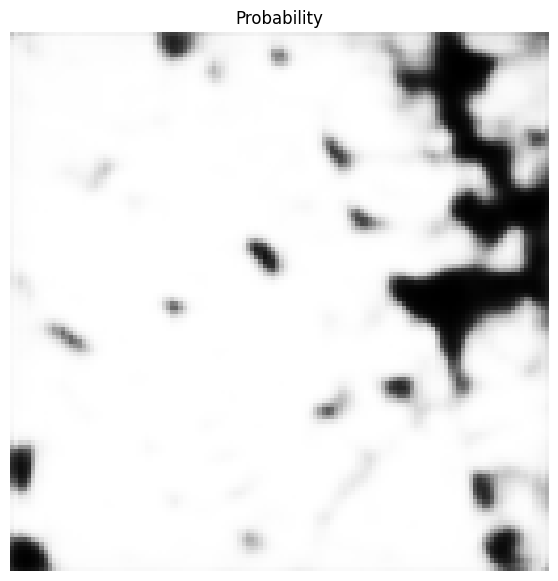

id: torch.Size([1])
sample_id: EMSR629_AOI01_09_01_1_2.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR629_AOI01_09_01_1_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR629_AOI01_09_01_1_2.tif
accuracy: 0.969482421875
precision: 0.9912713766098022
recall: 0.9774229526519775
f1: 0.9842984080314636
iou: 0.9690823554992676


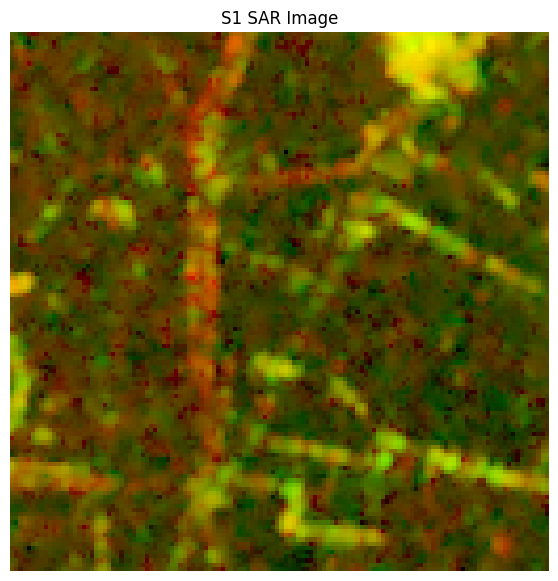

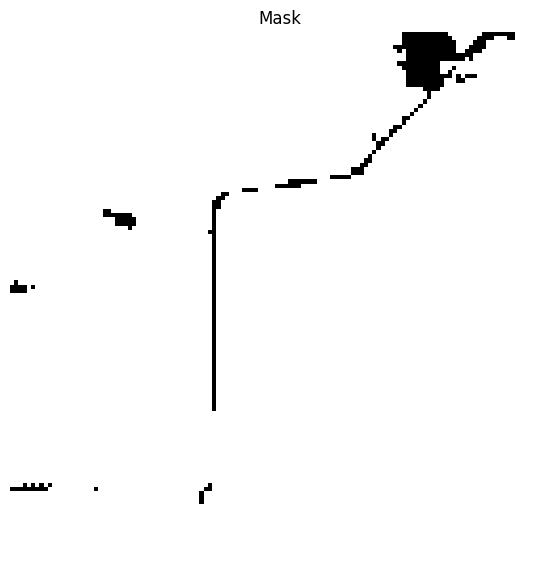

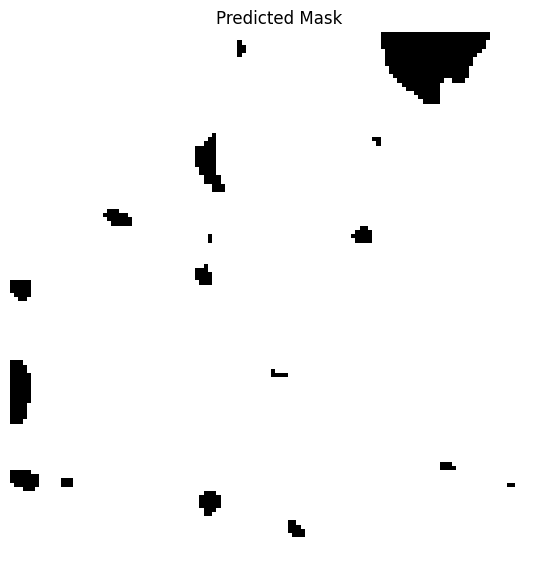

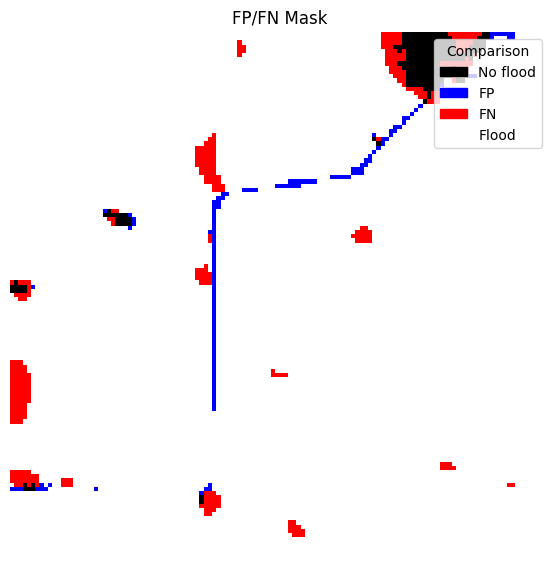

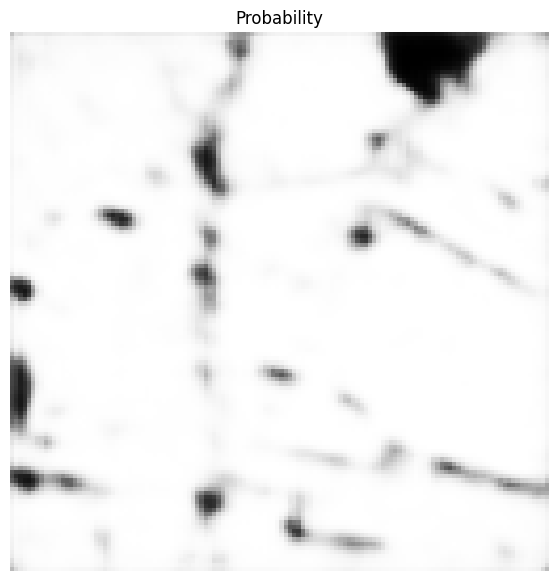

In [9]:
plot.plot_s1_results(results)